# Phương pháp 2 — Quantile Regression, từ đầu đến cuối

## Cơ chế

Thay vì train một model dự đoán **giá trung bình** rồi suy ra khoảng, ta train **model riêng cho
từng phân vị**. LightGBM hỗ trợ trực tiếp qua `objective="quantile"`:

```python
LGBMRegressor(objective="quantile", alpha=0.05)   # model du doan phan vi 5%
LGBMRegressor(objective="quantile", alpha=0.95)   # model du doan phan vi 95%
```

Hàm mất mát là **pinball loss** — phạt lệch trên và lệch dưới với trọng số khác nhau:

$$L_\alpha(y, \hat q) = \begin{cases} \alpha\,(y - \hat q) & y \ge \hat q \\ (1-\alpha)(\hat q - y) & y < \hat q \end{cases}$$

Với `α = 0.95`, dự đoán thấp bị phạt nặng gấp 19 lần dự đoán cao → model tự đẩy đầu ra lên sát
phân vị 95%. Khoảng 90% chính là `[q05, q95]`.

## Khác Conformal ở đâu

| | Conformal chuẩn hoá | Quantile Regression |
|---|---|---|
| Khoảng đến từ | **Sai số lịch sử** của model điểm | Model **học thẳng** hai đầu khoảng |
| Mỗi chuyến | Cùng một tỷ lệ `±q` | **Riêng** — hai đầu do feature quyết định |
| Đối xứng | ✅ luôn đối xứng quanh `p̂` | ❌ không cần đối xứng |
| Bảo đảm | ✅ Hữu hạn mẫu | ❌ **Không có** |

Điểm cuối là điều phải nói rõ: QR **không có bảo đảm nào**. Coverage đạt được là kết quả model
học tốt, không phải tính chất toán học. Model học lệch thì coverage lệch, và không có gì chặn lại.

Đó chính là lý do CQR ra đời — xem `03_CQR`.

## Model nền

`train/06_train_quantile_da_muc` train **7 phân vị × 3 tháng = 21 model**:
`0,05 · 0,10 · 0,15 · 0,50 · 0,85 · 0,90 · 0,95`. Đủ cho cả ba mức tin cậy 70 / 80 / 90%.

## Nội dung

| Phần | Nội dung | Hình |
|---|---|---|
| 1 | Coverage và độ rộng ở ba mức | `QR1` |
| 2 | Khoảng có **thích ứng** theo chuyến không | `QR2` |
| 3 | Phân rã theo band giá | `QR3` |
| 4 | Phân rã theo giờ và quãng đường | `QR4` |

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 13, "axes.labelsize": 11.5,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5, "legend.fontsize": 10.5,
})
EVAL = Path("../evaluation")
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

# 3 muc tin cay <-> cap phan vi. Bo 7 phan vi do train/06 sinh ra.
MUC_PV = {0.90: ("q05", "q95"), 0.80: ("q10", "q90"), 0.70: ("q15", "q85")}
MUCS = [0.70, 0.80, 0.90]
CANH = [0, 50e3, 100e3, 150e3, 200e3, 300e3, np.inf]
TEN = ["<50k", "50–100k", "100–150k", "150–200k", "200–300k", ">300k"]

qc = pd.read_parquet(EVAL / "qr_pred_da_muc_calibration.parquet")
qt = pd.read_parquet(EVAL / "qr_pred_da_muc_test.parquet")
uc = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")
ut = pd.read_parquet(EVAL / "uq_pred_test.parquet")

# Band chia theo GIA DU DOAN cua Hybrid — dung chung moi phuong phap thi moi so duoc
assert np.allclose(qt.gia_that.values, ut.gia_that.values), "test lech thu tu hang"
assert np.allclose(qc.gia_that.values, uc.gia_that.values), "calibration lech thu tu hang"
qt = qt.assign(band=pd.cut(ut.hybrid_pred.values, CANH, labels=TEN, right=False),
               p_hybrid=ut.hybrid_pred.values, gio_vn=ut.gio_vn.values,
               quote_distance=ut.quote_distance.values)
qc = qc.assign(band=pd.cut(uc.hybrid_pred.values, CANH, labels=TEN, right=False))

# q cua Conformal chuan hoa — de doi chieu (xem 01_conformal_chuan_hoa)
q90_conf = np.quantile(((uc.hybrid_pred - uc.gia_that).abs() / uc.hybrid_pred).values, .90)

print(f"Calibration {len(qc):,} | Test {len(qt):,}")
print(f"Phan vi co san: {[c for c in qt.columns if c.startswith('q') and c[1:].isdigit()]}")
print(f"Doi chieu — Conformal chuan hoa 90%: ±{q90_conf:.2%} "
      f"(do rong tuong doi {2*q90_conf:.1%} cho MOI chuyen)")

Calibration 615,908 | Test 864,360
Phan vi co san: ['q05', 'q10', 'q15', 'q50', 'q85', 'q90', 'q95']
Doi chieu — Conformal chuan hoa 90%: ±30.09% (do rong tuong doi 60.2% cho MOI chuyen)


## 1. Coverage và độ rộng ở ba mức tin cậy

Lấy thẳng hai phân vị làm khoảng, **không hiệu chỉnh gì**. Đây là QR thô.

In [2]:
def khoang_qr(d, muc):
    lo_a, hi_a = MUC_PV[muc]
    return d[lo_a].values, d[hi_a].values


rows = []
for muc in MUCS:
    lo, hi = khoang_qr(qt, muc)
    y = qt.gia_that.values
    trong = (y >= lo) & (y <= hi)
    rows.append({"Mức danh mục": f"{muc:.0%}",
                 "Phân vị": " – ".join(MUC_PV[muc]),
                 "Coverage đạt": f"{trong.mean():.2%}",
                 "Lệch": f"{(trong.mean()-muc)*100:+.2f} điểm",
                 "Độ rộng TB": f"{(hi-lo).mean():,.0f}đ",
                 "Độ rộng trung vị": f"{np.median(hi-lo):,.0f}đ",
                 "Trượt trên": f"{(y > hi).mean():.2%}",
                 "Trượt dưới": f"{(y < lo).mean():.2%}"})
BANG_QR = pd.DataFrame(rows)
display(BANG_QR)

print("Nhan xet: QR tho HUT coverage o ca ba muc — deu am.")
print("Do la dieu phai xay ra: khong co co che nao ep no dat danh muc.")

,Mức danh mục,Phân vị,Coverage đạt,Lệch,Độ rộng TB,Độ rộng trung vị,Trượt trên,Trượt dưới
0,70%,q15 – q85,68.88%,-1.12 điểm,"47,406đ","45,926đ",16.25%,14.88%
1,80%,q10 – q90,78.89%,-1.11 điểm,"58,772đ","56,959đ",11.11%,10.01%
2,90%,q05 – q95,89.09%,-0.91 điểm,"75,783đ","73,465đ",5.79%,5.12%


Nhan xet: QR tho HUT coverage o ca ba muc — deu am.
Do la dieu phai xay ra: khong co co che nao ep no dat danh muc.


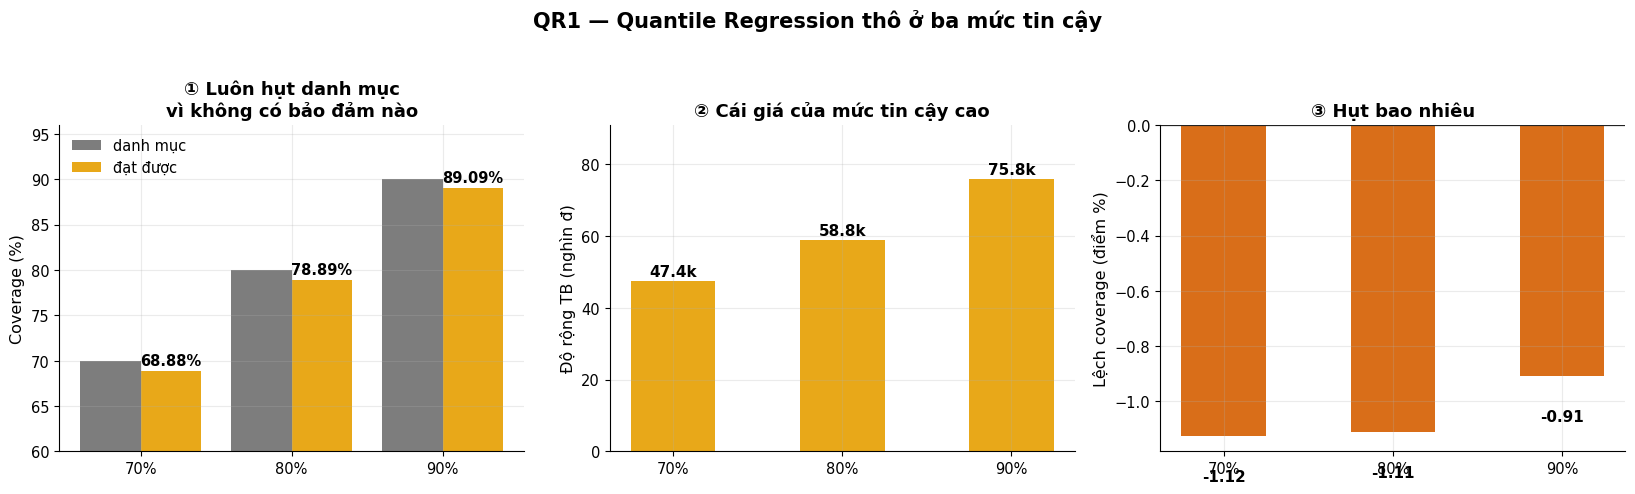

In [3]:
# ═════════ HINH QR1 — coverage va do rong ba muc ═════════
cov = [((qt.gia_that.values >= khoang_qr(qt, m)[0]) &
        (qt.gia_that.values <= khoang_qr(qt, m)[1])).mean() for m in MUCS]
rong = [(khoang_qr(qt, m)[1] - khoang_qr(qt, m)[0]).mean() for m in MUCS]

fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.8))
x = np.arange(len(MUCS))

ax[0].bar(x - .2, [m*100 for m in MUCS], .4, color=MUT, alpha=.85, label="danh mục")
ax[0].bar(x + .2, [c*100 for c in cov], .4, color=ORANGE, alpha=.9, label="đạt được")
for i, (m, c_) in enumerate(zip(MUCS, cov)):
    ax[0].text(i + .2, c_*100 + .6, f"{c_:.2%}", ha="center", fontsize=10.5,
               fontweight="bold")
ax[0].set_xticks(x); ax[0].set_xticklabels([f"{m:.0%}" for m in MUCS])
ax[0].set_ylabel("Coverage (%)"); ax[0].set_ylim(60, 96)
ax[0].legend(frameon=False)
ax[0].set_title("① Luôn hụt danh mục\nvì không có bảo đảm nào", fontweight="bold")

ax[1].bar(x, [r/1000 for r in rong], .5, color=ORANGE, alpha=.9)
for i, r in enumerate(rong):
    ax[1].text(i, r/1000 + 1.5, f"{r/1000:.1f}k", ha="center", fontsize=11,
               fontweight="bold")
ax[1].set_xticks(x); ax[1].set_xticklabels([f"{m:.0%}" for m in MUCS])
ax[1].set_ylabel("Độ rộng TB (nghìn đ)")
ax[1].set_ylim(0, max(rong)/1000*1.2)
ax[1].set_title("② Cái giá của mức tin cậy cao", fontweight="bold")

lech = [(c_ - m)*100 for c_, m in zip(cov, MUCS)]
ax[2].bar(x, lech, .5, color=[RED if v < 0 else GREEN for v in lech], alpha=.9)
ax[2].axhline(0, color=INK, lw=1.6)
for i, v in enumerate(lech):
    ax[2].text(i, v - .12, f"{v:+.2f}", ha="center", va="top", fontsize=11,
               fontweight="bold")
ax[2].set_xticks(x); ax[2].set_xticklabels([f"{m:.0%}" for m in MUCS])
ax[2].set_ylabel("Lệch coverage (điểm %)")
ax[2].set_title("③ Hụt bao nhiêu", fontweight="bold")

fig.suptitle("QR1 — Quantile Regression thô ở ba mức tin cậy",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "QR1_ba_muc.png"); plt.show()

## 2. Khoảng có thích ứng theo từng chuyến không

Đây là điểm QR hơn hẳn Conformal về nguyên lý: mỗi chuyến có khoảng riêng do feature quyết định,
không phải cùng một tỷ lệ.

Đo bằng cách xem **độ rộng tương đối** (`(hi−lo)/p̂`) phân tán ra sao. Conformal cho phân phối là
một điểm duy nhất (60,2%); QR càng phân tán thì càng thích ứng.

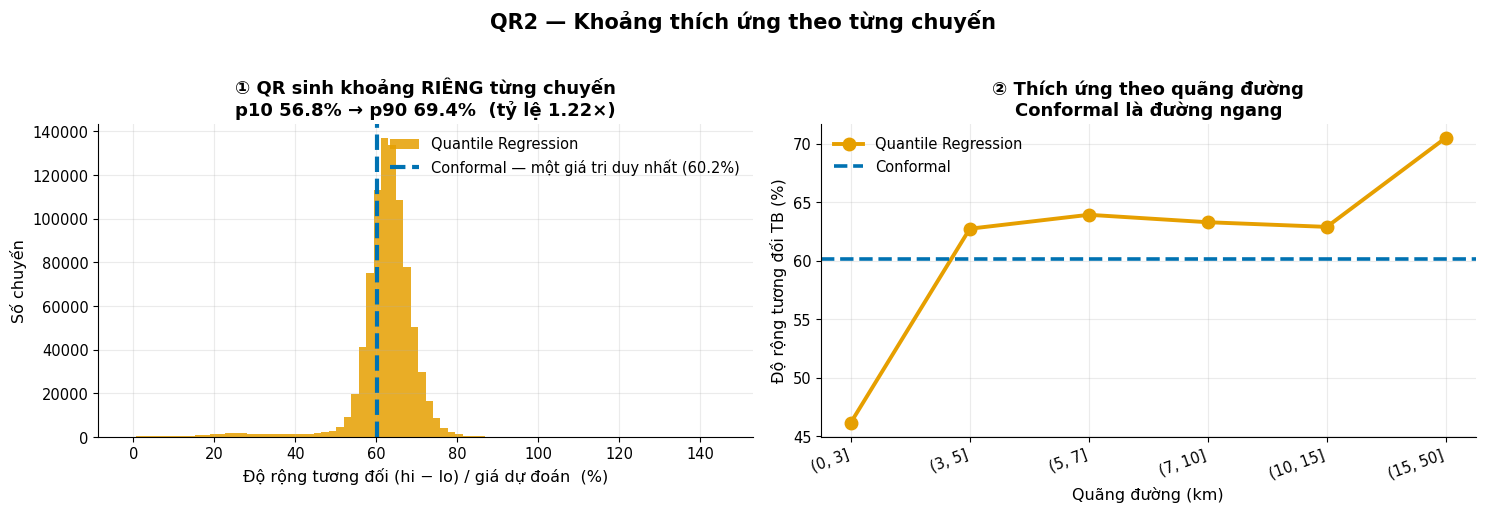

Do rong tuong doi QR: p10 56.81% · trung vi 63.06% · p90 69.45%
Conformal            : 60.18% cho MOI chuyen

=> QR thich ung that, nhung thich ung khong dong nghia voi DUNG.
   Phan 3 kiem xem no co dung khong.


In [4]:
# ═════════ HINH QR2 — do thich ung ═════════
lo, hi = khoang_qr(qt, 0.90)
rel_qr = (hi - lo) / qt.p_hybrid.values
rel_conf = np.full(len(qt), 2 * q90_conf)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].hist(rel_qr*100, bins=80, color=ORANGE, alpha=.85, label="Quantile Regression")
ax[0].axvline(rel_conf[0]*100, color=BLUE, lw=3, ls="--",
              label=f"Conformal — một giá trị duy nhất ({rel_conf[0]:.1%})")
ax[0].set_xlabel("Độ rộng tương đối (hi − lo) / giá dự đoán  (%)")
ax[0].set_ylabel("Số chuyến")
ax[0].legend(frameon=False)
p10, p90 = np.percentile(rel_qr, [10, 90])
ax[0].set_title(f"① QR sinh khoảng RIÊNG từng chuyến\n"
                f"p10 {p10:.1%} → p90 {p90:.1%}  (tỷ lệ {p90/p10:.2f}×)",
                fontweight="bold")

# Thich ung theo cai gi? Xem do rong tuong doi theo quang duong
d = qt.assign(rel=rel_qr, km=pd.cut(qt.quote_distance, [0, 3, 5, 7, 10, 15, 50]))
gg = d.groupby("km", observed=True).rel.mean()
ax[1].plot(range(len(gg)), gg*100, marker="o", ms=9, lw=2.8, color=ORANGE,
           label="Quantile Regression")
ax[1].axhline(rel_conf[0]*100, color=BLUE, lw=2.6, ls="--", label="Conformal")
ax[1].set_xticks(range(len(gg)))
ax[1].set_xticklabels([str(i) for i in gg.index], rotation=20, ha="right")
ax[1].set_xlabel("Quãng đường (km)"); ax[1].set_ylabel("Độ rộng tương đối TB (%)")
ax[1].legend(frameon=False)
ax[1].set_title("② Thích ứng theo quãng đường\nConformal là đường ngang", fontweight="bold")

fig.suptitle("QR2 — Khoảng thích ứng theo từng chuyến", fontweight="bold",
             fontsize=15, y=1.02)
plt.tight_layout(); plt.savefig(HINH / "QR2_thich_ung.png"); plt.show()

print(f"Do rong tuong doi QR: p10 {p10:.2%} · trung vi {np.median(rel_qr):.2%} · "
      f"p90 {p90:.2%}")
print(f"Conformal            : {rel_conf[0]:.2%} cho MOI chuyen")
print()
print("=> QR thich ung that, nhung thich ung khong dong nghia voi DUNG.")
print("   Phan 3 kiem xem no co dung khong.")

## 3. Phân rã theo band giá

Đây là chỗ QR bù lại điểm yếu lớn nhất của Conformal. Conformal áp một tỷ lệ chung nên band giá
cao bị hụt 7,3 điểm. QR sinh phân vị riêng từng chuyến — có đều hơn không?

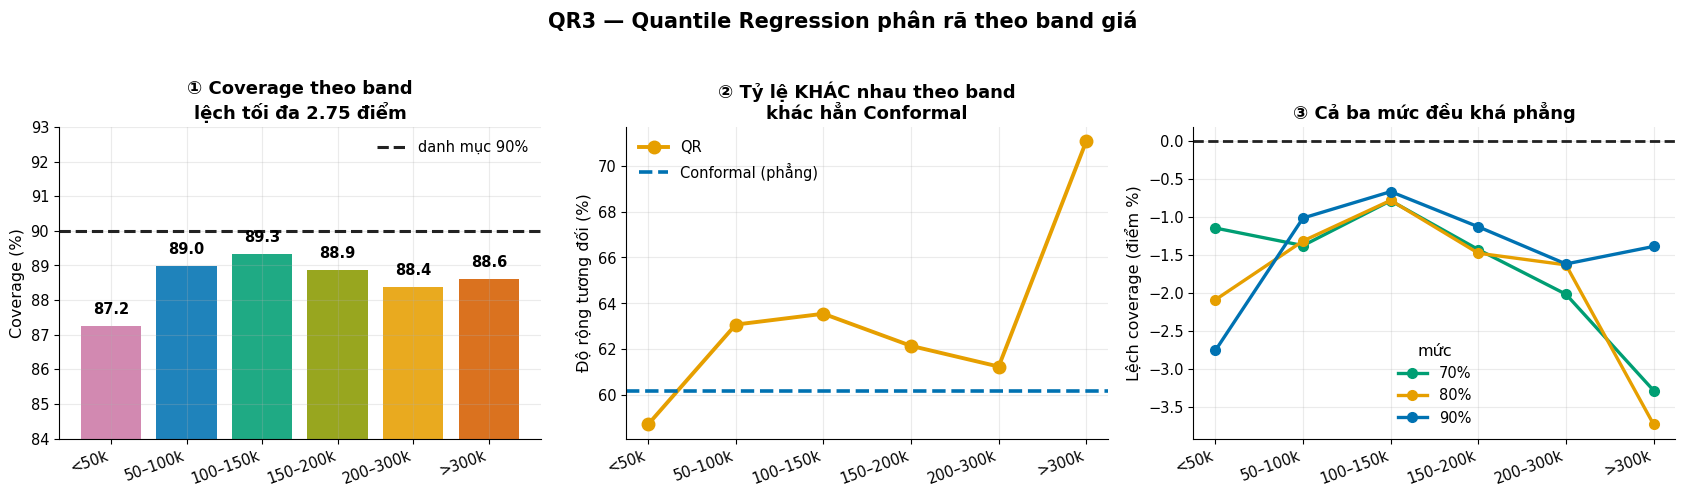

      Band         n   coverage     rong TV     rel    tren    duoi
--------------------------------------------------------------------
      <50k    10,821     87.25%     26,125d   58.7%   4.25%   8.50%
   50–100k   264,201     88.99%     54,057d   63.1%   5.12%   5.90%
  100–150k   409,883     89.34%     76,770d   63.5%   5.77%   4.89%
  150–200k   149,324     88.87%    104,229d   62.1%   6.63%   4.50%
  200–300k    28,875     88.38%    134,017d   61.2%   8.38%   3.23%
     >300k     1,256     88.61%    242,086d   71.1%   8.84%   2.55%


In [5]:
# ═════════ HINH QR3 — theo band gia ═════════
def theo_band(muc):
    lo, hi = khoang_qr(qt, muc)
    d = pd.DataFrame({"band": qt.band.values, "y": qt.gia_that.values,
                      "p": qt.p_hybrid.values, "lo": lo, "hi": hi})
    d["trong"] = (d.y >= d.lo) & (d.y <= d.hi)
    d["rong"] = d.hi - d.lo
    d["rel"] = d.rong / d.p
    d["tren"] = d.y > d.hi
    d["duoi"] = d.y < d.lo
    return d.groupby("band", observed=True).agg(
        n=("y", "size"), cvg=("trong", "mean"), rong=("rong", "median"),
        rel=("rel", "median"), tren=("tren", "mean"),
        duoi=("duoi", "mean")).reindex(TEN)


G = {m: theo_band(m) for m in MUCS}
g90 = G[0.90]

fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
x = np.arange(len(TEN))
MAU_BAND = [PURPLE, BLUE, GREEN, "#8A9A00", ORANGE, RED]

ax[0].bar(x, g90.cvg*100, color=MAU_BAND, alpha=.88)
ax[0].axhline(90, color=INK, lw=2.2, ls="--", label="danh mục 90%")
for i, v in enumerate(g90.cvg*100):
    ax[0].text(i, v + .35, f"{v:.1f}", ha="center", fontsize=10.5, fontweight="bold")
ax[0].set_xticks(x); ax[0].set_xticklabels(TEN, rotation=20, ha="right")
ax[0].set_ylabel("Coverage (%)"); ax[0].set_ylim(84, 93)
ax[0].legend(frameon=False)
ax[0].set_title(f"① Coverage theo band\nlệch tối đa {abs(g90.cvg*100-90).max():.2f} điểm",
                fontweight="bold")

ax[1].plot(x, g90.rel*100, marker="o", ms=9, lw=2.8, color=ORANGE, label="QR")
ax[1].axhline(2*q90_conf*100, color=BLUE, lw=2.6, ls="--", label="Conformal (phẳng)")
ax[1].set_xticks(x); ax[1].set_xticklabels(TEN, rotation=20, ha="right")
ax[1].set_ylabel("Độ rộng tương đối (%)")
ax[1].legend(frameon=False)
ax[1].set_title("② Tỷ lệ KHÁC nhau theo band\nkhác hẳn Conformal", fontweight="bold")

for m, col in zip(MUCS, [GREEN, ORANGE, BLUE]):
    ax[2].plot(x, (G[m].cvg - m)*100, marker="o", ms=7, lw=2.4, color=col,
               label=f"{m:.0%}")
ax[2].axhline(0, color=INK, lw=2, ls="--")
ax[2].set_xticks(x); ax[2].set_xticklabels(TEN, rotation=20, ha="right")
ax[2].set_ylabel("Lệch coverage (điểm %)")
ax[2].legend(frameon=False, title="mức")
ax[2].set_title("③ Cả ba mức đều khá phẳng", fontweight="bold")

fig.suptitle("QR3 — Quantile Regression phân rã theo band giá",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "QR3_theo_band.png"); plt.show()

print(f"{'Band':>10s} {'n':>9s} {'coverage':>10s} {'rong TV':>11s} {'rel':>7s} "
      f"{'tren':>7s} {'duoi':>7s}")
print("-" * 68)
for b in TEN:
    r = g90.loc[b]
    print(f"{b:>10s} {int(r.n):>9,} {r.cvg:>10.2%} {r.rong:>10,.0f}d {r.rel:>7.1%} "
          f"{r.tren:>7.2%} {r.duoi:>7.2%}")

## 4. Phân rã theo giờ và quãng đường

Hai chiều còn lại. Nếu QR đều ở cả ba chiều thì coverage điều kiện của nó thật sự tốt.

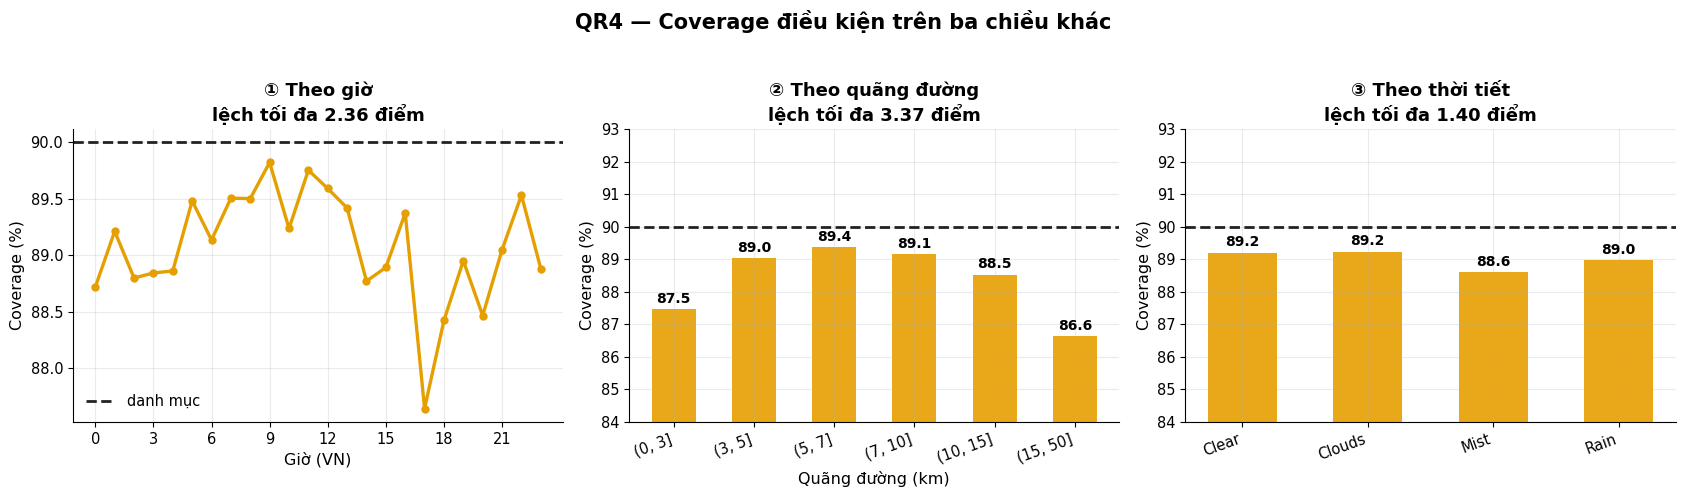

Lech coverage toi da (diem %):
  theo band giá   : 2.75
  theo giờ        : 2.36
  theo quãng đường: 3.37
  theo thời tiết  : 1.40


In [6]:
# ═════════ HINH QR4 — theo gio va quang duong ═════════
lo, hi = khoang_qr(qt, 0.90)
d = qt.assign(lo=lo, hi=hi)
d["trong"] = (d.gia_that >= d.lo) & (d.gia_that <= d.hi)
d["rel"] = (d.hi - d.lo) / d.p_hybrid
d["km"] = pd.cut(d.quote_distance, [0, 3, 5, 7, 10, 15, 50])

fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))

gh = d.groupby("gio_vn", observed=True).agg(cvg=("trong", "mean"), rel=("rel", "mean"))
ax[0].plot(gh.index, gh.cvg*100, marker="o", ms=5, lw=2.4, color=ORANGE)
ax[0].axhline(90, color=INK, lw=2, ls="--", label="danh mục")
ax[0].set_xlabel("Giờ (VN)"); ax[0].set_ylabel("Coverage (%)")
ax[0].set_xticks(range(0, 24, 3)); ax[0].legend(frameon=False)
ax[0].set_title(f"① Theo giờ\nlệch tối đa {abs(gh.cvg*100-90).max():.2f} điểm",
                fontweight="bold")

gk = d.groupby("km", observed=True).agg(cvg=("trong", "mean"), rel=("rel", "mean"))
xx = np.arange(len(gk))
ax[1].bar(xx, gk.cvg*100, .55, color=ORANGE, alpha=.9)
ax[1].axhline(90, color=INK, lw=2, ls="--")
for i, v in enumerate(gk.cvg*100):
    ax[1].text(i, v + .2, f"{v:.1f}", ha="center", fontsize=10, fontweight="bold")
ax[1].set_xticks(xx); ax[1].set_xticklabels([str(i) for i in gk.index],
                                            rotation=20, ha="right")
ax[1].set_ylabel("Coverage (%)"); ax[1].set_ylim(84, 93)
ax[1].set_xlabel("Quãng đường (km)")
ax[1].set_title(f"② Theo quãng đường\nlệch tối đa {abs(gk.cvg*100-90).max():.2f} điểm",
                fontweight="bold")

gw = d.groupby("weather_main", observed=True).agg(cvg=("trong", "mean"))
xw = np.arange(len(gw))
ax[2].bar(xw, gw.cvg*100, .55, color=ORANGE, alpha=.9)
ax[2].axhline(90, color=INK, lw=2, ls="--")
for i, v in enumerate(gw.cvg*100):
    ax[2].text(i, v + .2, f"{v:.1f}", ha="center", fontsize=10, fontweight="bold")
ax[2].set_xticks(xw); ax[2].set_xticklabels(gw.index, rotation=20, ha="right")
ax[2].set_ylabel("Coverage (%)"); ax[2].set_ylim(84, 93)
ax[2].set_title(f"③ Theo thời tiết\nlệch tối đa {abs(gw.cvg*100-90).max():.2f} điểm",
                fontweight="bold")

fig.suptitle("QR4 — Coverage điều kiện trên ba chiều khác", fontweight="bold",
             fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "QR4_coverage_dieu_kien.png"); plt.show()

print("Lech coverage toi da (diem %):")
print(f"  theo band giá   : {abs(g90.cvg*100-90).max():.2f}")
print(f"  theo giờ        : {abs(gh.cvg*100-90).max():.2f}")
print(f"  theo quãng đường: {abs(gk.cvg*100-90).max():.2f}")
print(f"  theo thời tiết  : {abs(gw.cvg*100-90).max():.2f}")

---

# Kết luận về phương pháp 2

| | |
|---|---|
| **Điểm mạnh** | Khoảng **thích ứng từng chuyến** · coverage điều kiện đều hơn Conformal rõ rệt · khoảng **không cần đối xứng** nên bắt được đuôi lệch phải của giá |
| **Điểm yếu** | **Không có bảo đảm nào** — coverage luôn hụt danh mục khoảng 1 điểm · phải train và lưu 21 model · khoảng rộng hơn Conformal |
| **Khi nào dùng** | Khi coverage điều kiện quan trọng hơn độ rộng, và chấp nhận hụt ~1 điểm |

Điểm yếu "không có bảo đảm" sửa được: lấy khoảng của QR rồi hiệu chỉnh bằng conformal.
Đó chính là **CQR** — xem `03_CQR`.